In [1]:
from train_vit_v2 import  *
import inspect
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from PIL import Image
import numpy as np


from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torch
from torch.nn import DataParallel
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.functional")

from sklearn.metrics.pairwise import cosine_similarity

In [4]:
class ImageDataset(Dataset):
    def __init__(self, img_path):
        """
        img_path can be either a directory containing images or a path to a single image.
        """
        if os.path.isdir(img_path):
            self.img_dir = img_path
            self.image_names = [img for img in sorted(os.listdir(img_path))
                                if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        elif os.path.isfile(img_path) and img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            self.img_dir, single_image_name = os.path.split(img_path)
            self.image_names = [single_image_name]  # Single image in a list
        else:
            raise ValueError(f"Provided path '{img_path}' is neither a directory nor a file, or file type is not supported.")

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.52997664, 0.48070561, 0.41943838],
                                 std=[0.27608301, 0.26593025, 0.28238822])
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, index):
        image_name = self.image_names[index]
        img_path = os.path.join(self.img_dir, image_name)
        image = Image.open(img_path).convert('RGB')  # Ensure image is RGB
        image = self.transform(image)
        
        return image_name, image


class CLIP(nn.Module):
    def __init__(self, classnames, backbone_name='RN50', pos_embedding=False):
        super().__init__()

        self.num_clip = len(classnames)
        self.clip_model = load_clip_to_cpu(backbone_name)
        self.pos_embedding = pos_embedding

        # Disable gradients for all parameters first
        for param in self.clip_model.parameters():
            param.requires_grad = False
        
        # Tokenize all prompts at once and store them as a tensor
        self.tokenized_prompts = torch.stack([clip.tokenize(classname) for classname in classnames])


    def forward(self, image):
        if self.clip_model.training:
            self.clip_model.eval()

        # Move tokenized prompts to the same device as the input image
        tokenized_prompts = self.tokenized_prompts.to(image.device)

        # Process all tokenized prompts in a single forward pass
        image_feature, text_feature = self.clip_model(image, tokenized_prompts, self.pos_embedding)

        return image_feature, text_feature
    
    def init_weights(self, pretrained=None, strict=True):
        """Init weights for models.

        Args:
            pretrained (str, optional): Path for pretrained weights. If given
                None, pretrained weights will not be loaded. Defaults: None.
            strict (boo, optional): Whether strictly load the pretrained model.
                Defaults to True.
        """
        if isinstance(pretrained, str):
            logger = get_root_logger()
            load_checkpoint(self, pretrained, strict=strict, logger=logger)
        elif pretrained is not None:
            raise TypeError(f'"pretrained" must be a str or None. '
                            f'But received {type(pretrained)}.')


def run_image(model, data_loader, device=torch.device("cuda:0")):
    model.eval()
    model.to(device)
    
    progress_bar = tqdm(enumerate(data_loader), total=len(data_loader), desc=f"Processing images")
    
    with torch.no_grad():
        for batch_idx, (batch_image_names, batch_images) in progress_bar:
            batch_images = batch_images.to(device)
            x, y = model(batch_images)
            print(x.shape, y.shape)
            
    return x, y


if __name__ == '__main__':
    
    ########################################
    img_dir = '/home/wallacelab/CLIP-IQA/CLIP-HBA/Data/HebartImage1854'
    lora = True
    load_hba = False
    n_dim = 66 # options: 49, 66
    backbone = 'ViT-L/14'
    model_path = "./models/test_models/cliphba_1v1t_contribution.pth"
    batch_size = 1854 #1854/2
    vision_layers = 1
    transormer_layers = 1
    ########################################

    if n_dim == 49:
        classnames = classnames49
    elif n_dim == 66:
        classnames = classnames66
    else: 
        raise ValueError("n_dim must be either 49 or 66")
    
    if backbone == 'RN50':
        pos_embedding = False
        print("pos_embedding is False")
    if backbone == 'ViT-B/16' or backbone == 'ViT-B/32' or backbone == 'ViT-L/14': 
        pos_embedding = True
        print("pos_embedding is True")

    model = CLIP(classnames=classnames, backbone_name=backbone, pos_embedding=pos_embedding)


    if lora:
        apply_lora_to_ViT(model, n_vision_layers=vision_layers, n_transformer_layers=transormer_layers, r=8, lora_dropout=0.1)

    if load_hba:
        model_state_dict = torch.load(model_path)
        adjusted_state_dict = {key.replace("module.", ""): value for key, value in model_state_dict.items()}
        model.load_state_dict(adjusted_state_dict)
    else:
        print("Model is not loaded with HBA weights")

    
    # Load the dataset
    dataset = ImageDataset(img_dir)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    # Run the model and save output embeddings
    image_features, text_features = run_image(model, data_loader)
    image_features = image_features.cpu().numpy()
    text_features = text_features.cpu().numpy()

    #make feature rdms
    image_features_rdm = 1 - cosine_similarity(image_features)
    text_features_rdm = 1 - cosine_similarity(text_features)
    np.fill_diagonal(image_features_rdm, 0)
    np.fill_diagonal(text_features_rdm, 0)

    print(image_features_rdm.shape, text_features_rdm.shape)

pos_embedding is True
Model is not loaded with HBA weights


Processing images: 100%|██████████| 1/1 [00:23<00:00, 23.80s/it]

torch.Size([1854, 768]) torch.Size([132, 768])
(1854, 1854) (132, 132)


In [5]:
np.save('../output/image_features_rdm_original.npy', image_features_rdm)
np.save('../output/text_features_rdm_original.npy', text_features_rdm)

In [7]:
original_image_rdm = np.load('../output/image_features_rdm_original.npy')
original_text_rdm = np.load('../output/text_features_rdm_original.npy')
hba_image_rdm = np.load('../output/image_features_rdm_hba.npy')
hba_text_rdm = np.load('../output/text_features_rdm_hba.npy')

Text(0.5, 1.0, 'HBA Text RDM')

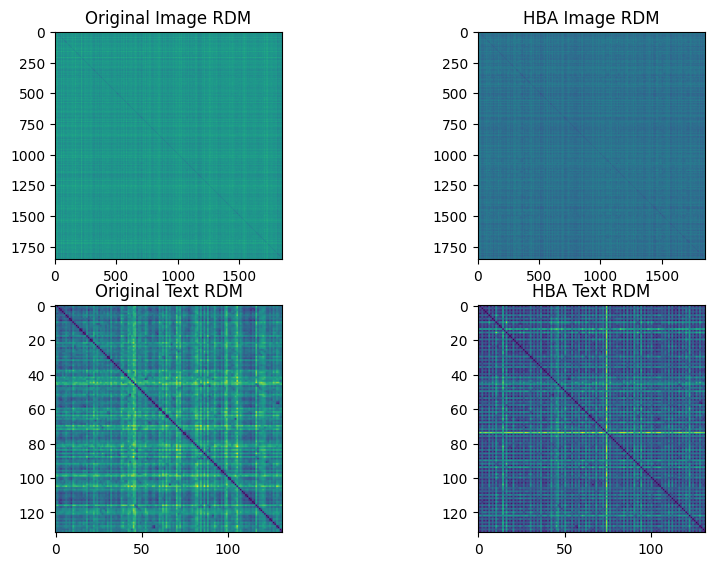

In [8]:
plt.figure(figsize=(10, 6.5))
plt.subplot(2, 2, 1)
plt.imshow(original_image_rdm, cmap='viridis')
plt.title('Original Image RDM')

plt.subplot(2, 2, 2)
plt.imshow(hba_image_rdm, cmap='viridis')
plt.title('HBA Image RDM')

plt.subplot(2, 2, 3)
plt.imshow(original_text_rdm, cmap='viridis')
plt.title('Original Text RDM')

plt.subplot(2, 2, 4)
plt.imshow(hba_text_rdm, cmap='viridis')
plt.title('HBA Text RDM')


In [10]:
from scipy.stats import pearsonr
img_corr, _ = pearsonr(original_image_rdm.flatten(), hba_image_rdm.flatten())
txt_corr, _ = pearsonr(original_text_rdm.flatten(), hba_text_rdm.flatten())

print(f"Image RDM correlation: {img_corr}")
print(f"Text RDM correlation: {txt_corr}")

Image RDM correlation: 0.48195078709168515
Text RDM correlation: 0.4398430234862992
